# Análisis reproducible del Registro Nacional de Turismo — RNT en Colombia

## Sección 1 — Introducción y pregunta de análisis

Este proyecto analiza el dataset **Registro Nacional de Turismo — RNT**, disponible en el portal Datos Abiertos Colombia. El RNT es un registro público de prestadores de servicios turísticos que operan en Colombia.

**Pregunta de análisis:**

> ¿Cómo se distribuyen los prestadores de servicios turísticos inscritos en el Registro Nacional de Turismo en Colombia según departamento, municipio, categoría, estado del registro y capacidad reportada?

Esta pregunta es relevante porque permite identificar la concentración territorial de la oferta turística registrada, las categorías predominantes y algunos indicadores de capacidad, como habitaciones, camas y empleados reportados.


## Sección 2 — Configuración inicial y carga de librerías

In [16]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Permite importar funciones desde la carpeta src/
sys.path.append("../src")

from utilidades_rnt import (
    normalizar_columnas,
    buscar_columna,
    convertir_numerica,
    guardar_tabla,
)

RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
OUTPUT_TABLES = Path("../outputs/tablas")
OUTPUT_CHARTS = Path("../outputs/graficos")

for folder in [RAW_DIR, PROCESSED_DIR, OUTPUT_TABLES, OUTPUT_CHARTS]:
    folder.mkdir(parents=True, exist_ok=True)

RAW_FILE = RAW_DIR / "registro_nacional_turismo_rnt.csv"
PROCESSED_FILE = PROCESSED_DIR / "registro_nacional_turismo_rnt_limpio.csv"

RAW_FILE

WindowsPath('../data/raw/registro_nacional_turismo_rnt.csv')

## Sección 3 — Descarga o carga del dataset

El notebook intenta leer el archivo local desde `data/raw/`. Si no existe, intenta descargarlo desde la API pública de Datos Abiertos Colombia.

> Nota: si la descarga automática no funciona por conexión o cambios del portal, descargue manualmente el CSV desde la página del dataset y guárdelo con el nombre `registro_nacional_turismo_rnt.csv` dentro de `data/raw/`.


In [17]:
# API pública del dataset Registro Nacional de Turismo - RNT.
# Se usa un límite alto. Si el archivo queda muy grande, se puede bajar el límite o trabajar por filtros.
DATA_URL = "https://www.datos.gov.co/resource/thwd-ivmp.csv?$limit=500000"

if RAW_FILE.exists():
    print("Leyendo archivo local:", RAW_FILE)
    df_raw = pd.read_csv(RAW_FILE)
else:
    print("Intentando descargar el dataset desde Datos Abiertos Colombia...")
    try:
        df_raw = pd.read_csv(DATA_URL)
        df_raw.to_csv(RAW_FILE, index=False, encoding="utf-8")
        print("Archivo descargado y guardado en:", RAW_FILE)
    except Exception as e:
        raise RuntimeError(
            "No fue posible descargar el dataset automáticamente. "
            "Descargue el CSV manualmente desde Datos Abiertos Colombia y guárdelo en data/raw/ "
            "con el nombre registro_nacional_turismo_rnt.csv."
        ) from e

df_raw.head()

Intentando descargar el dataset desde Datos Abiertos Colombia...


C:\Users\sandi\AppData\Local\Temp\ipykernel_22756\3494029795.py:11: DtypeWarning: Columns (0: nit) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv(DATA_URL)


Archivo descargado y guardado en: ..\data\raw\registro_nacional_turismo_rnt.csv


,codigo_rnt,estado_rnt,razon_social_establecimiento,departamento,cod_dpto,municipio,cod_mun,nit,categoria,sub_categoria,habitaciones,camas,num_emp1,ano
0,11,ACTIVO,BCD TRAVEL OFICINA PRINCIPAL,BOGOTA,11,BOGOTA D.C.,11001,800078692,AGENCIA DE VIAJES,AGENCIAS DE VIAJES Y DE TURISMO,0,0,367,2019
1,20,ACTIVO,LUBEL.COM,BOGOTA,11,BOGOTA D.C.,11001,860501706,OFICINAS DE REPRESENTACION TURÍSTICA,OFICINA DE REPRESENTACION TURÍSTICA,0,0,3,2019
2,43,ACTIVO,HOTEL LOS BALCONES,CAUCA,19,POPAYAN,19001,891501824,ESTABLECIMIENTOS DE ALOJAMIENTO TURÍSTICO,HOTEL,8,16,4,2019
3,55,ACTIVO,AGRUPACION DE REPRESENTACIONES COMERCIALES,BOGOTA,11,BOGOTA D.C.,11001,860352462,OFICINAS DE REPRESENTACION TURÍSTICA,OFICINA DE REPRESENTACION TURÍSTICA,0,0,8,2019
4,56,ACTIVO,REVEL REPRESENTACIONES TURISTICAS,BOGOTA,11,BOGOTA D.C.,11001,860527703,OFICINAS DE REPRESENTACION TURÍSTICA,OFICINA DE REPRESENTACION TURÍSTICA,0,0,6,2019


## Sección 4 — Exploración inicial del dataset

In [18]:
print("Dimensiones del dataset:", df_raw.shape)
df_raw.info()

Dimensiones del dataset: (500000, 14)
<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 14 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   codigo_rnt                    500000 non-null  int64 
 1   estado_rnt                    500000 non-null  str   
 2   razon_social_establecimiento  499946 non-null  str   
 3   departamento                  500000 non-null  str   
 4   cod_dpto                      500000 non-null  int64 
 5   municipio                     500000 non-null  str   
 6   cod_mun                       500000 non-null  int64 
 7   nit                           500000 non-null  object
 8   categoria                     500000 non-null  str   
 9   sub_categoria                 500000 non-null  str   
 10  habitaciones                  500000 non-null  int64 
 11  camas                         500000 non-null  int64 
 12  num_emp1                      5

In [21]:
df_raw.head(10)

,codigo_rnt,estado_rnt,razon_social_establecimiento,departamento,cod_dpto,municipio,cod_mun,nit,categoria,sub_categoria,habitaciones,camas,num_emp1,ano
0,11,ACTIVO,BCD TRAVEL OFICINA PRINCIPAL,BOGOTA,11,BOGOTA D.C.,11001,800078692,AGENCIA DE VIAJES,AGENCIAS DE VIAJES Y DE TURISMO,0,0,367,2019
1,20,ACTIVO,LUBEL.COM,BOGOTA,11,BOGOTA D.C.,11001,860501706,OFICINAS DE REPRESENTACION TURÍSTICA,OFICINA DE REPRESENTACION TURÍSTICA,0,0,3,2019
2,43,ACTIVO,HOTEL LOS BALCONES,CAUCA,19,POPAYAN,19001,891501824,ESTABLECIMIENTOS DE ALOJAMIENTO TURÍSTICO,HOTEL,8,16,4,2019
3,55,ACTIVO,AGRUPACION DE REPRESENTACIONES COMERCIALES,BOGOTA,11,BOGOTA D.C.,11001,860352462,OFICINAS DE REPRESENTACION TURÍSTICA,OFICINA DE REPRESENTACION TURÍSTICA,0,0,8,2019
4,56,ACTIVO,REVEL REPRESENTACIONES TURISTICAS,BOGOTA,11,BOGOTA D.C.,11001,860527703,OFICINAS DE REPRESENTACION TURÍSTICA,OFICINA DE REPRESENTACION TURÍSTICA,0,0,6,2019
5,61,ACTIVO,AVIATUR CARTAGENA,BOLIVAR,13,CARTAGENA,13001,860000018,AGENCIA DE VIAJES,AGENCIAS DE VIAJES Y DE TURISMO,0,0,38,2019
6,68,ACTIVO,AVIATUR CALI LA FLORA,VALLE DEL CAUCA,76,CALI,76001,860000018,AGENCIA DE VIAJES,AGENCIAS DE VIAJES Y DE TURISMO,0,0,57,2019
7,72,ACTIVO,AVIATUR CIUDAD JARDIN,VALLE DEL CAUCA,76,CALI,76001,860000018,AGENCIA DE VIAJES,AGENCIAS DE VIAJES Y DE TURISMO,0,0,2,2019
8,73,ACTIVO,AVIATUR AVENIDA COLOMBIA,VALLE DEL CAUCA,76,CALI,76001,860000018,AGENCIA DE VIAJES,AGENCIAS DE VIAJES Y DE TURISMO,0,0,3,2019
9,79,ACTIVO,AVIATUR BARRANQUILLA,ATLANTICO,8,BARRANQUILLA,8001,860000018,AGENCIA DE VIAJES,AGENCIAS DE VIAJES Y DE TURISMO,0,0,22,2019


In [22]:
df_raw.describe(include="all")

,codigo_rnt,estado_rnt,razon_social_establecimiento,departamento,cod_dpto,municipio,cod_mun,nit,categoria,sub_categoria,habitaciones,camas,num_emp1,ano
count,500000.000000,500000,499946,500000,500000.000000,500000,500000.000000,500000.0,500000,500000,500000.000000,500000.000000,500000.000000,500000.000000
unique,NaN,1,152814,34,NaN,948,NaN,166077.0,29,72,NaN,NaN,NaN,NaN
top,NaN,ACTIVO,JALO RENT SAS,ANTIOQUIA,NaN,BOGOTA D.C.,NaN,901005631.0,VIVIENDAS TURÍSTICAS,APARTAMENTO TURÍSTICO,NaN,NaN,NaN,NaN
freq,NaN,500000,1839,88654,NaN,58226,NaN,1676.0,229317,115123,NaN,NaN,NaN,NaN
mean,104062.885202,NaN,NaN,NaN,33.827286,NaN,34070.322912,NaN,NaN,NaN,6.424718,11.912408,3.140022,2022.508762
std,56900.465347,NaN,NaN,NaN,27.490440,NaN,27503.216194,NaN,NaN,NaN,32.264152,52.891629,38.700349,1.795639
min,11.000000,NaN,NaN,NaN,0.000000,NaN,1.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,2019.000000
25%,58784.000000,NaN,NaN,NaN,11.000000,NaN,11001.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,2021.000000
50%,98292.000000,NaN,NaN,NaN,23.000000,NaN,23672.000000,NaN,NaN,NaN,1.000000,4.000000,1.000000,2023.000000
75%,147066.250000,NaN,NaN,NaN,63.000000,NaN,63130.000000,NaN,NaN,NaN,6.000000,12.000000,1.000000,2024.000000


## Sección 5 — Limpieza y normalización

Se normalizan los nombres de columnas para facilitar el análisis. Luego se identifican las columnas principales: año, departamento, municipio, categoría, subcategoría, estado del registro, habitaciones, camas y empleados.


In [23]:
df = normalizar_columnas(df_raw)

print(df.columns.tolist())

['codigo_rnt', 'estado_rnt', 'razon_social_establecimiento', 'departamento', 'cod_dpto', 'municipio', 'cod_mun', 'nit', 'categoria', 'sub_categoria', 'habitaciones', 'camas', 'num_emp1', 'ano']


In [24]:
# Posibles nombres de columnas según el dataset y variaciones del portal
col_ano = buscar_columna(df, ["ano", "anio", "a_o"])
col_mes = buscar_columna(df, ["mes"])
col_codigo_rnt = buscar_columna(df, ["codigo_rnt", "cod_rnt", "rnt"])
col_estado = buscar_columna(df, ["estado_rnt", "estado", "estado_del_rnt"])
col_razon_social = buscar_columna(df, ["razon_social_establecimiento", "razon_social", "establecimiento"])
col_departamento = buscar_columna(df, ["departamento", "depto", "nombre_departamento"])
col_municipio = buscar_columna(df, ["municipio", "nombre_municipio"])
col_categoria = buscar_columna(df, ["categoria", "categor_a"])
col_subcategoria = buscar_columna(df, ["sub_categoria", "subcategoria", "sub_categor_a"])
col_habitaciones = buscar_columna(df, ["habitaciones", "num_habitaciones"])
col_camas = buscar_columna(df, ["camas", "num_camas"])
col_empleados = buscar_columna(df, ["num_emp1", "empleados", "numero_empleados", "num_empleados"])

columnas_detectadas = {
    "año": col_ano,
    "mes": col_mes,
    "codigo_rnt": col_codigo_rnt,
    "estado": col_estado,
    "razon_social": col_razon_social,
    "departamento": col_departamento,
    "municipio": col_municipio,
    "categoria": col_categoria,
    "subcategoria": col_subcategoria,
    "habitaciones": col_habitaciones,
    "camas": col_camas,
    "empleados": col_empleados,
}

columnas_detectadas

{'año': 'ano',
 'mes': None,
 'codigo_rnt': 'codigo_rnt',
 'estado': 'estado_rnt',
 'razon_social': 'razon_social_establecimiento',
 'departamento': 'departamento',
 'municipio': 'municipio',
 'categoria': 'categoria',
 'subcategoria': 'sub_categoria',
 'habitaciones': 'habitaciones',
 'camas': 'camas',
 'empleados': 'num_emp1'}

In [25]:
# Validación mínima
obligatorias = {
    "departamento": col_departamento,
    "municipio": col_municipio,
    "categoria": col_categoria,
}

faltantes = [nombre for nombre, columna in obligatorias.items() if columna is None]

if faltantes:
    raise ValueError(
        f"No se detectaron columnas obligatorias: {faltantes}. "
        "Revise los nombres reales de las columnas en el dataset."
    )

# Convertir variables numéricas si existen
for columna in [col_ano, col_habitaciones, col_camas, col_empleados]:
    df = convertir_numerica(df, columna)

# Eliminar registros sin departamento, municipio o categoría
df_limpio = df.dropna(subset=[col_departamento, col_municipio, col_categoria]).copy()

# Si existe código RNT, eliminar duplicados exactos de código para evitar conteos repetidos
if col_codigo_rnt is not None:
    registros_antes = len(df_limpio)
    df_limpio = df_limpio.drop_duplicates(subset=[col_codigo_rnt], keep="first")
    print("Duplicados por código RNT eliminados:", registros_antes - len(df_limpio))

print("Dimensiones luego de limpieza:", df_limpio.shape)
df_limpio.head()

Duplicados por código RNT eliminados: 313493
Dimensiones luego de limpieza: (186507, 14)


,codigo_rnt,estado_rnt,razon_social_establecimiento,departamento,cod_dpto,municipio,cod_mun,nit,categoria,sub_categoria,habitaciones,camas,num_emp1,ano
0,11,ACTIVO,BCD TRAVEL OFICINA PRINCIPAL,BOGOTA,11,BOGOTA D.C.,11001,800078692,AGENCIA DE VIAJES,AGENCIAS DE VIAJES Y DE TURISMO,0,0,367,2019
1,20,ACTIVO,LUBEL.COM,BOGOTA,11,BOGOTA D.C.,11001,860501706,OFICINAS DE REPRESENTACION TURÍSTICA,OFICINA DE REPRESENTACION TURÍSTICA,0,0,3,2019
2,43,ACTIVO,HOTEL LOS BALCONES,CAUCA,19,POPAYAN,19001,891501824,ESTABLECIMIENTOS DE ALOJAMIENTO TURÍSTICO,HOTEL,8,16,4,2019
3,55,ACTIVO,AGRUPACION DE REPRESENTACIONES COMERCIALES,BOGOTA,11,BOGOTA D.C.,11001,860352462,OFICINAS DE REPRESENTACION TURÍSTICA,OFICINA DE REPRESENTACION TURÍSTICA,0,0,8,2019
4,56,ACTIVO,REVEL REPRESENTACIONES TURISTICAS,BOGOTA,11,BOGOTA D.C.,11001,860527703,OFICINAS DE REPRESENTACION TURÍSTICA,OFICINA DE REPRESENTACION TURÍSTICA,0,0,6,2019


In [26]:
# Guardar dataset procesado
df_limpio.to_csv(PROCESSED_FILE, index=False, encoding="utf-8")
PROCESSED_FILE

WindowsPath('../data/processed/registro_nacional_turismo_rnt_limpio.csv')

## Sección 6 — Análisis exploratorio

### 6.1 Registros por departamento


In [27]:
registros_departamento = (
    df_limpio.groupby(col_departamento, as_index=False)
    .size()
    .rename(columns={"size": "numero_registros"})
    .sort_values("numero_registros", ascending=False)
)

guardar_tabla(registros_departamento, OUTPUT_TABLES / "registros_por_departamento.csv")
registros_departamento.head(15)

,departamento,numero_registros
1,ANTIOQUIA,36200
4,BOGOTA,23145
5,BOLIVAR,19566
19,MAGDALENA,13842
14,CUNDINAMARCA,13553
31,VALLE DEL CAUCA,12412
28,SANTANDER,7000
25,QUINDIO,6889
6,BOYACA,6712
30,TOLIMA,6132


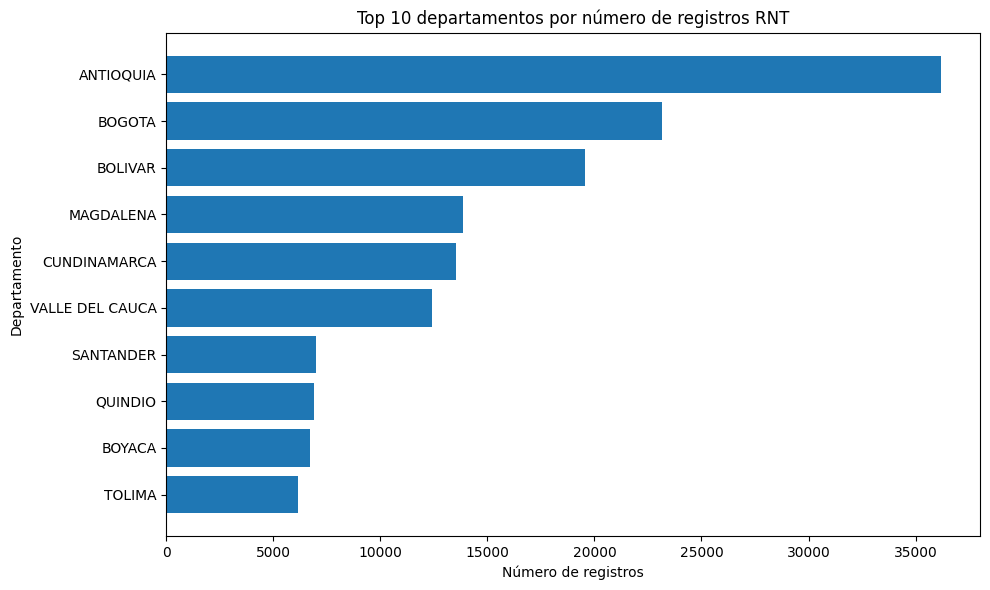

In [28]:
top_departamentos = registros_departamento.head(10).sort_values("numero_registros")

plt.figure(figsize=(10, 6))
plt.barh(top_departamentos[col_departamento], top_departamentos["numero_registros"])
plt.title("Top 10 departamentos por número de registros RNT")
plt.xlabel("Número de registros")
plt.ylabel("Departamento")
plt.tight_layout()
plt.savefig(OUTPUT_CHARTS / "top_10_departamentos_rnt.png", dpi=150)
plt.show()

### 6.2 Registros por municipio

In [29]:
registros_municipio = (
    df_limpio.groupby(col_municipio, as_index=False)
    .size()
    .rename(columns={"size": "numero_registros"})
    .sort_values("numero_registros", ascending=False)
)

guardar_tabla(registros_municipio, OUTPUT_TABLES / "registros_por_municipio.csv")
registros_municipio.head(15)

,municipio,numero_registros
92,BOGOTA D.C.,22438
479,MEDELLIN,18916
146,CARTAGENA,18863
754,SANTA MARTA,13519
125,CALI,7519
77,BARRANQUILLA,3766
577,PEREIRA,3225
692,SAN ANDRES,2663
57,ARMENIA,2567
372,IBAGUE,2258


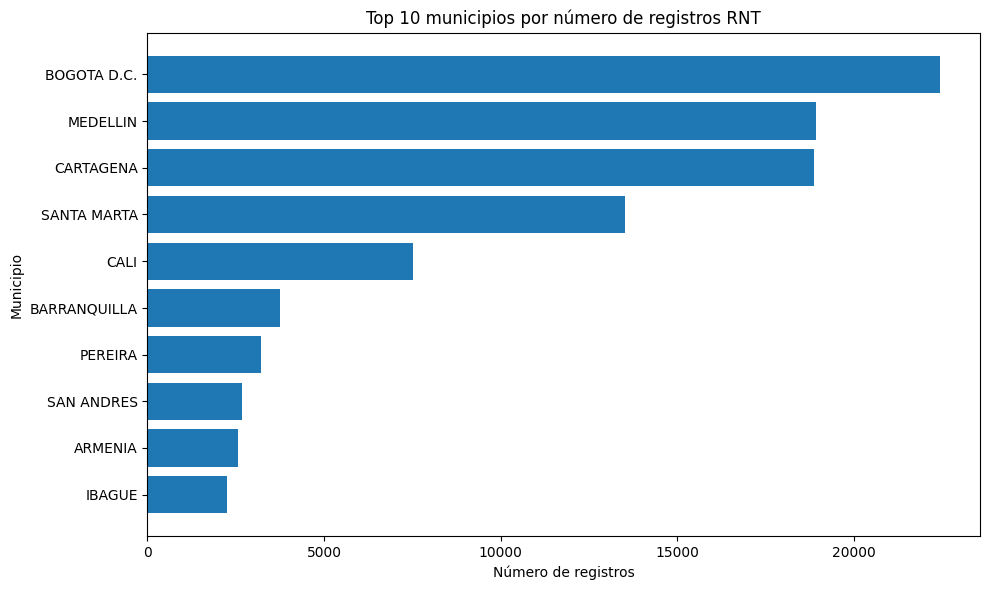

In [30]:
top_municipios = registros_municipio.head(10).sort_values("numero_registros")

plt.figure(figsize=(10, 6))
plt.barh(top_municipios[col_municipio], top_municipios["numero_registros"])
plt.title("Top 10 municipios por número de registros RNT")
plt.xlabel("Número de registros")
plt.ylabel("Municipio")
plt.tight_layout()
plt.savefig(OUTPUT_CHARTS / "top_10_municipios_rnt.png", dpi=150)
plt.show()

### 6.3 Registros por categoría

In [31]:
registros_categoria = (
    df_limpio.groupby(col_categoria, as_index=False)
    .size()
    .rename(columns={"size": "numero_registros"})
    .sort_values("numero_registros", ascending=False)
)

guardar_tabla(registros_categoria, OUTPUT_TABLES / "registros_por_categoria.csv")
registros_categoria.head(15)

,categoria,numero_registros
28,VIVIENDAS TURÍSTICAS,100299
14,ESTABLECIMIENTOS DE ALOJAMIENTO TURÍSTICO,31064
0,AGENCIA DE VIAJES,14823
24,OTROS TIPOS DE HOSPEDAJE TURÍSTICOS NO PERMANE...,12117
1,AGENCIAS DE VIAJES,11928
17,GUIA DE TURISMO,3093
18,GUIAS DE TURISMO,2377
13,ESTABLECIMIENTO DE GASTRONOMÍA Y SIMILARES,2091
21,OPERADORES PROFESIONALES DE CONGRESOS FERIAS Y...,1598
19,OFICINAS DE REPRESENTACION TURÍSTICA,1413


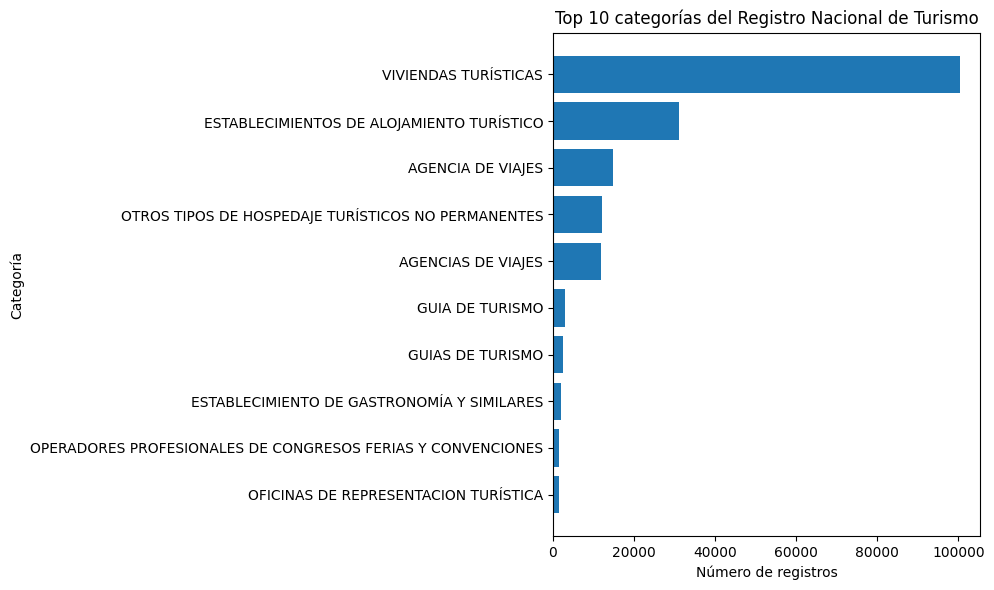

In [32]:
top_categorias = registros_categoria.head(10).sort_values("numero_registros")

plt.figure(figsize=(10, 6))
plt.barh(top_categorias[col_categoria], top_categorias["numero_registros"])
plt.title("Top 10 categorías del Registro Nacional de Turismo")
plt.xlabel("Número de registros")
plt.ylabel("Categoría")
plt.tight_layout()
plt.savefig(OUTPUT_CHARTS / "top_10_categorias_rnt.png", dpi=150)
plt.show()

### 6.4 Estado del registro RNT

Este análisis se ejecuta si existe una columna de estado del registro.


In [33]:
if col_estado is not None:
    registros_estado = (
        df_limpio.groupby(col_estado, as_index=False)
        .size()
        .rename(columns={"size": "numero_registros"})
        .sort_values("numero_registros", ascending=False)
    )
    guardar_tabla(registros_estado, OUTPUT_TABLES / "registros_por_estado.csv")
    display(registros_estado)
else:
    print("No se detectó columna de estado del registro.")

,estado_rnt,numero_registros
0,ACTIVO,186507


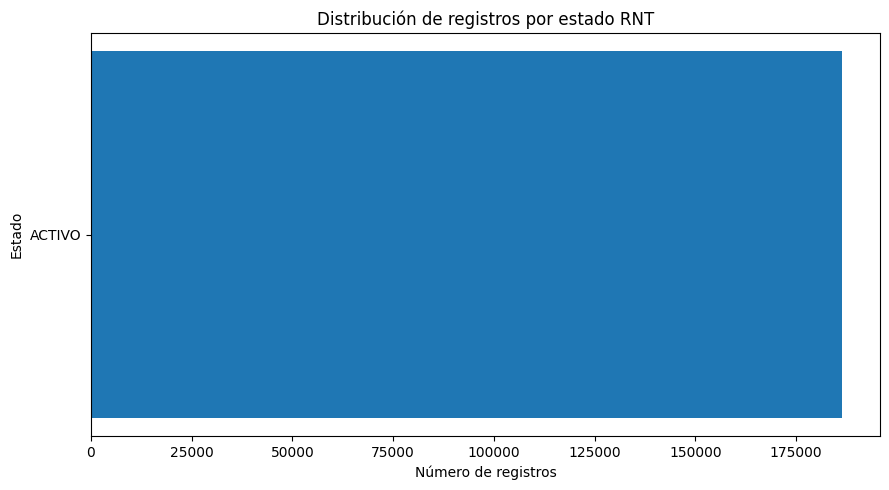

In [34]:
if col_estado is not None:
    estados = registros_estado.sort_values("numero_registros")

    plt.figure(figsize=(9, 5))
    plt.barh(estados[col_estado], estados["numero_registros"])
    plt.title("Distribución de registros por estado RNT")
    plt.xlabel("Número de registros")
    plt.ylabel("Estado")
    plt.tight_layout()
    plt.savefig(OUTPUT_CHARTS / "registros_por_estado_rnt.png", dpi=150)
    plt.show()

### 6.5 Capacidad reportada: habitaciones, camas y empleados

Este análisis se ejecuta si las columnas existen en el dataset.


In [35]:
capacidad_cols = [c for c in [col_habitaciones, col_camas, col_empleados] if c is not None]

if capacidad_cols:
    resumen_capacidad = df_limpio[capacidad_cols].describe().T
    guardar_tabla(resumen_capacidad.reset_index().rename(columns={"index": "variable"}), OUTPUT_TABLES / "resumen_capacidad.csv")
    display(resumen_capacidad)
else:
    print("No se detectaron columnas de capacidad como habitaciones, camas o empleados.")

,count,mean,std,min,25%,50%,75%,max
habitaciones,186507.0,4.987261,28.846085,0.0,1.0,1.0,4.0,5105.0
camas,186507.0,9.054293,37.385211,0.0,1.0,4.0,10.0,4500.0
num_emp1,186507.0,1.651681,20.899720,0.0,0.0,0.0,1.0,2761.0


In [36]:
if capacidad_cols and col_departamento is not None:
    capacidad_departamento = (
        df_limpio.groupby(col_departamento, as_index=False)[capacidad_cols]
        .sum()
        .sort_values(capacidad_cols[0], ascending=False)
    )
    guardar_tabla(capacidad_departamento, OUTPUT_TABLES / "capacidad_por_departamento.csv")
    display(capacidad_departamento.head(15))

,departamento,habitaciones,camas,num_emp1
1,ANTIOQUIA,147625,290371,41868
4,BOGOTA,112966,129522,61841
14,CUNDINAMARCA,72570,136996,13438
5,BOLIVAR,69932,139901,28732
31,VALLE DEL CAUCA,68043,114845,24056
19,MAGDALENA,50274,116539,14026
30,TOLIMA,43295,83648,7096
28,SANTANDER,42513,75245,14090
6,BOYACA,33802,65623,6451
25,QUINDIO,31258,63749,6249


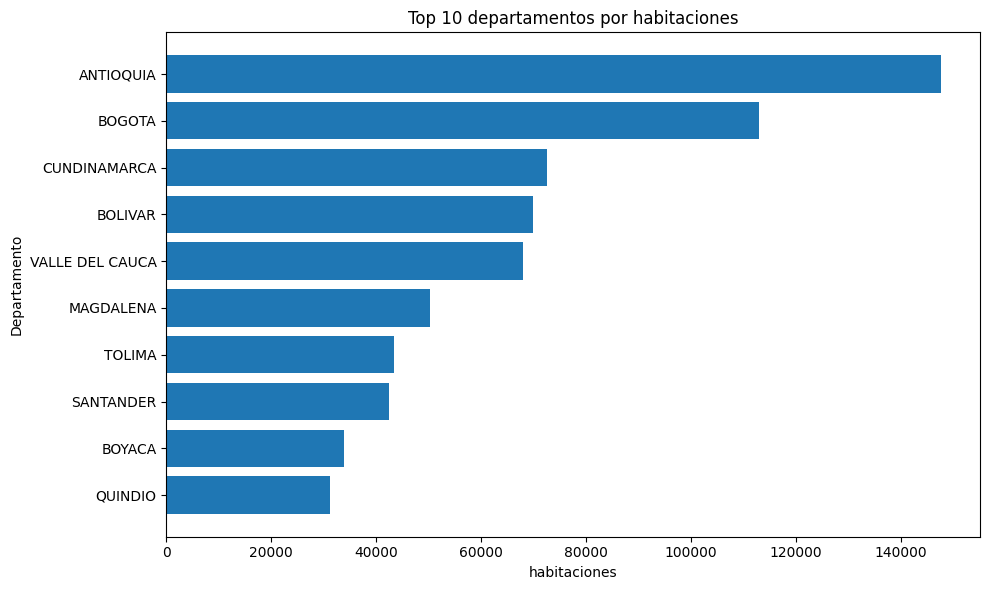

In [37]:
if capacidad_cols and col_departamento is not None:
    variable_capacidad = capacidad_cols[0]
    top_capacidad = capacidad_departamento.head(10).sort_values(variable_capacidad)

    plt.figure(figsize=(10, 6))
    plt.barh(top_capacidad[col_departamento], top_capacidad[variable_capacidad])
    plt.title(f"Top 10 departamentos por {variable_capacidad}")
    plt.xlabel(variable_capacidad)
    plt.ylabel("Departamento")
    plt.tight_layout()
    plt.savefig(OUTPUT_CHARTS / f"top_10_departamentos_por_{variable_capacidad}.png", dpi=150)
    plt.show()

### 6.6 Evolución por año

Este análisis se ejecuta si existe una columna de año.


In [38]:
if col_ano is not None:
    registros_ano = (
        df_limpio.groupby(col_ano, as_index=False)
        .size()
        .rename(columns={"size": "numero_registros"})
        .sort_values(col_ano)
    )
    guardar_tabla(registros_ano, OUTPUT_TABLES / "registros_por_ano.csv")
    display(registros_ano)
else:
    print("No se detectó columna de año.")

,ano,numero_registros
0,2019,43209
1,2020,10597
2,2021,19999
3,2022,37554
4,2023,37831
5,2024,37310
6,2025,7


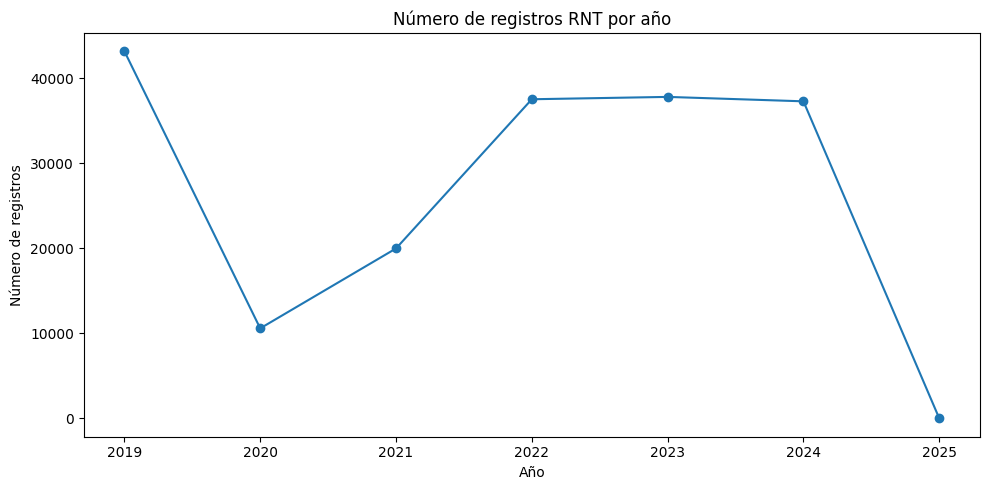

In [39]:
if col_ano is not None:
    plt.figure(figsize=(10, 5))
    plt.plot(registros_ano[col_ano], registros_ano["numero_registros"], marker="o")
    plt.title("Número de registros RNT por año")
    plt.xlabel("Año")
    plt.ylabel("Número de registros")
    plt.tight_layout()
    plt.savefig(OUTPUT_CHARTS / "registros_por_ano_rnt.png", dpi=150)
    plt.show()


## Sección 7 — Conclusiones

El análisis del Registro Nacional de Turismo — RNT evidencia que la oferta turística formal registrada en Colombia presenta una alta concentración territorial. A nivel departamental, **Antioquia** ocupa el primer lugar con **36.200 registros**, seguida por **Bogotá** con **23.145**, **Bolívar** con **19.566**, **Magdalena** con **13.842**, **Cundinamarca** con **13.553** y **Valle del Cauca** con **12.412**. Estos resultados muestran que una parte importante de los prestadores turísticos activos se concentra en territorios con alta actividad económica, conectividad, infraestructura y reconocimiento turístico.

En contraste, departamentos como **Vaupés** con **56 registros**, **Guainía** con **120**, **Vichada** con **122** y **Arauca** con **247** presentan los valores más bajos. Esta diferencia permite concluir que existe una distribución desigual de la oferta turística formal en el país. Sin embargo, estos resultados no deben interpretarse como ausencia de potencial turístico, sino como una menor presencia de prestadores inscritos o formalizados en el RNT.

A nivel municipal, la concentración también es evidente. Los municipios con mayor número de registros son **Bogotá D.C.** con **22.438**, **Medellín** con **18.916**, **Cartagena** con **18.863**, **Santa Marta** con **13.519** y **Cali** con **7.519**. Esta distribución confirma el peso de las principales capitales y destinos turísticos consolidados dentro del registro. También aparecen municipios con fuerte vocación turística, como **San Andrés**, **Villa de Leyva**, **Guatapé**, **Coveñas**, **Salento**, **Santa Rosa de Cabal**, **San Gil**, **Barichara**, **Filandia**, **Tolú** y **Leticia**, lo que muestra que el RNT no solo refleja la concentración en grandes ciudades, sino también en destinos intermedios y locales con actividad turística reconocida.

En cuanto a las categorías, el RNT está dominado por servicios asociados al alojamiento. La categoría con mayor número de registros es **Viviendas turísticas**, con **100.299 registros**, seguida por **Establecimientos de alojamiento turístico**, con **31.064**, y **Otros tipos de hospedaje turísticos no permanentes**, con **12.117**. Esto indica que una parte muy importante de la oferta turística formal registrada corresponde a servicios de hospedaje. También se observa una presencia relevante de las agencias de viajes, con **14.823 registros** en la categoría **Agencia de viajes** y **11.928** en **Agencias de viajes**.

Un hallazgo importante es la existencia de categorías similares registradas con nombres diferentes, por ejemplo **Agencia de viajes** y **Agencias de viajes**, **Guía de turismo** y **Guías de turismo**, o **Establecimiento de gastronomía y similares** y **Establecimientos de gastronomía y similares**. Esto evidencia la necesidad de realizar procesos de homologación y limpieza más detallados antes de hacer análisis más avanzados, ya que las variaciones en singular, plural o redacción pueden fragmentar categorías que conceptualmente pertenecen al mismo grupo.

Respecto al estado del registro, todos los datos analizados aparecen en estado **ACTIVO**, con un total de **186.507 registros**. Por esta razón, el análisis debe interpretarse como una caracterización de prestadores turísticos activos o vigentes en el RNT. Esta condición fortalece la utilidad del análisis para describir la oferta turística formal actual, pero también representa una limitación, porque no permite comparar registros activos con registros suspendidos, cancelados, vencidos o inactivos.

La capacidad turística reportada también muestra una fuerte concentración. **Antioquia** lidera en infraestructura de alojamiento, con **147.625 habitaciones** y **290.371 camas**, seguida por **Bogotá**, con **112.966 habitaciones** y **129.522 camas**. En cuanto al empleo reportado, **Bogotá** ocupa el primer lugar con **61.841 empleados**, seguida por **Antioquia** con **41.868** y **Bolívar** con **28.732**. Estos resultados indican que Antioquia tiene la mayor capacidad física de alojamiento, mientras que Bogotá concentra el mayor número de empleos reportados en el RNT.

También se destacan **Cundinamarca**, **Bolívar**, **Valle del Cauca** y **Magdalena**, que presentan valores elevados en habitaciones, camas y empleo. En contraste, **Vaupés**, **Guainía**, **Vichada**, **Guaviare** y **Arauca** reportan los menores valores en capacidad turística. Esto confirma que la infraestructura turística formal y la capacidad operativa se concentran en un grupo reducido de departamentos, mientras que otros territorios muestran una presencia más limitada dentro del registro.

En síntesis, el análisis permite concluir que la oferta turística formal activa en Colombia se concentra principalmente en **Antioquia, Bogotá, Bolívar, Magdalena, Cundinamarca y Valle del Cauca**, así como en municipios de alta actividad turística como **Bogotá D.C., Medellín, Cartagena, Santa Marta y Cali**. Además, la estructura del RNT está marcada por el predominio de las **viviendas turísticas**, los **establecimientos de alojamiento** y las **agencias de viajes**. El análisis es descriptivo y no permite establecer causalidades; para profundizar sería necesario integrar otras fuentes de información, como número de visitantes, ingresos turísticos, población municipal, empleo sectorial, ubicación geográfica, infraestructura vial y políticas de promoción turística.



## Sección 8 — Uso de IA documentado

Durante el desarrollo de este proyecto se utilizó **GitHub Copilot** y **ChatGPT** como herramientas de apoyo para la organización, revisión y mejora del análisis reproducible. Su uso no reemplazó el criterio propio del autor, sino que sirvió como acompañamiento técnico para comprender mejor el flujo de trabajo con GitHub, Python, Jupyter Notebook y el análisis de datos.

### Uso de GitHub Copilot

GitHub Copilot se utilizó dentro de Visual Studio Code como asistente de programación. Su apoyo fue útil para revisar fragmentos de código, explicar errores, sugerir mejoras en funciones de limpieza de datos, orientar la ejecución del notebook y facilitar la comprensión de algunas instrucciones en Python.

Algunas solicitudes realizadas a Copilot fueron:

- “Revisa la estructura de este proyecto de análisis reproducible en Python”.
- “Explícame qué hace este notebook paso a paso”.
- “Ayúdame a corregir este error de pandas”.
- “Mejora este gráfico de barras horizontal con matplotlib”.
- “Ayúdame a revisar una función para normalizar nombres de columnas”.

Las respuestas de Copilot fueron revisadas antes de incorporarse al proyecto. En varios casos fue necesario ajustar rutas de archivos, nombres de columnas, títulos de gráficos y explicaciones para que coincidieran con la estructura real del dataset del Registro Nacional de Turismo — RNT.

### Uso de ChatGPT

ChatGPT se utilizó como apoyo para interpretar las instrucciones del trabajo final, organizar el proyecto paso a paso, formular la pregunta de análisis y estructurar el repositorio y la documentación del uso de IA.

Algunas solicitudes realizadas a ChatGPT fueron:

- Ayudar a comprender los requerimientos del proyecto final.
- Proponer datasets actuales de Colombia adecuados para un análisis reproducible.
- Orientar la creación de la estructura del repositorio en GitHub.
- Explicar cómo crear y activar un entorno virtual en Visual Studio Code.
- Ayudar a resolver errores durante la instalación de librerías y ejecución del notebook.
- Revisión de la redacción de conclusiones a partir de las tablas generadas por el análisis.
- Proponer mensajes de commit claros para mantener un historial limpio en GitHub.

### Qué aportó la IA

Las herramientas de IA aportaron principalmente en cuatro aspectos:

1. **Organización del proyecto:** ayudaron a definir una estructura ordenada de carpetas y archivos.
2. **Apoyo técnico:** orientaron la instalación de dependencias, el uso del entorno virtual y la ejecución del notebook.
3. **Programación:** sugirieron código inicial para cargar, limpiar, resumir y visualizar datos.
4. **Documentación:** apoyaron la revisión de redacción del README, la documentación del uso de IA y las conclusiones descriptivas.

### Qué se corrigió o ajustó

Las respuestas generadas por IA fueron revisadas y adaptadas. Se ajustaron nombres reales de columnas del dataset, rutas de archivos, mensajes de error, títulos de gráficos y conclusiones. También se verificó que las interpretaciones fueran descriptivas y no afirmaran causalidad, ya que el análisis realizado corresponde a una exploración inicial del Registro Nacional de Turismo.

### Reflexión crítica sobre el uso de IA

El uso de GitHub Copilot y ChatGPT facilitó el desarrollo del proyecto, especialmente porque permitió comprender mejor el proceso de trabajo con GitHub, VS Code, Jupyter Notebook y Python. Sin embargo, fue necesario revisar críticamente cada sugerencia antes de aceptarla. La IA puede proponer código o textos útiles, pero no garantiza que estos sean correctos para el dataset específico.

En este proyecto, la IA funcionó como una herramienta de apoyo para aprender, organizar y mejorar el trabajo, mientras que las decisiones finales sobre el análisis, la interpretación de los resultados y la presentación del proyecto fueron asumidas por el autor.